# **Práctica 2:** Autoencoders


**Uso de librerías**

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


**Carga y Preprocesamiento del Dataset MNIST**  
Se define una transformación para convertir imágenes a tensores y normalizarlas a [−1,1]. Luego, se cargan los datasets MNIST de entrenamiento y prueba, y se configuran DataLoaders para manejar los datos en lotes de 64. Finalmente, se obtiene un lote de datos para verificar la normalización aplicada.

In [4]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
])

mnist_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
data_loader = torch.utils.data.DataLoader(dataset=mnist_data, batch_size=64, shuffle=True)

mnist_data_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
data_loader_test = torch.utils.data.DataLoader(dataset=mnist_data_test, batch_size=64, shuffle=True)

dataiter = iter(data_loader)
images, labels = next(dataiter)
print(torch.min(images), torch.max(images))

tensor(-1.) tensor(1.)


**Definición del Modelo de Autoencoder**  
Se define un autoencoder con un encoder que reduce la dimensionalidad de la entrada y un decoder que reconstruye la entrada original. El método forward pasa los datos por ambas partes del modelo y devuelve la reconstrucción.

In [5]:
class Autoenconder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1,16,3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(16,32,3,stride = 2,padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64,7)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64,32,7),
            nn.ReLU(),
            nn.ConvTranspose2d(32,16,3,stride=2,padding=1,output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1,3,stride=2,padding=1,output_padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

 ## Primera parte de la práctica: Eliminación del ruido



**Entrenamiento de Autoencoder con Ruido**

Se entrena un autoencoder agregando ruido gaussiano a las imágenes. El modelo aprende a reconstruir las imágenes originales, minimizando la pérdida MSE. Después, se visualizan las imágenes originales, con ruido y reconstruidas.

Epoca: 1, Loss: 0.2792
Epoca: 2, Loss: 0.1365
Epoca: 3, Loss: 0.1050
Epoca: 4, Loss: 0.0651
Epoca: 5, Loss: 0.0674
Epoca: 6, Loss: 0.0485
Epoca: 7, Loss: 0.0511
Epoca: 8, Loss: 0.0500
Epoca: 9, Loss: 0.0486
Epoca: 10, Loss: 0.0428


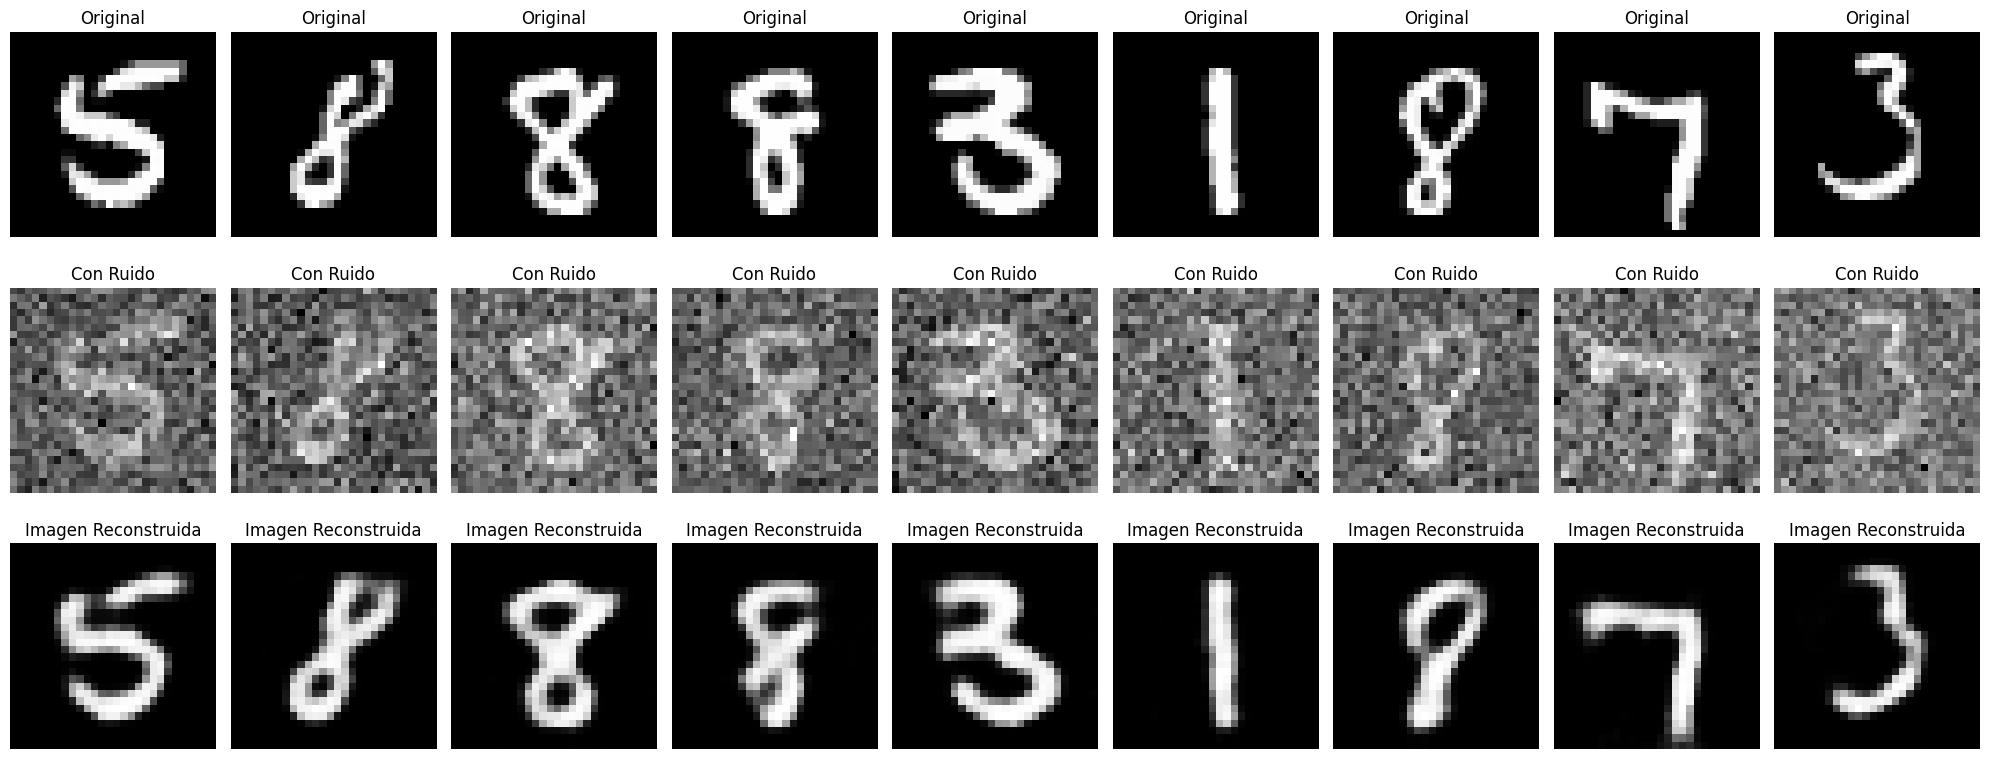

In [6]:
modelo = Autoenconder()

criterio = nn.MSELoss()
optimizador = torch.optim.Adam(modelo.parameters(), lr=1e-4, weight_decay=1e-6)

def add_gaussian_noise(images, mean=0.0, std=0.8):
    noise = torch.randn_like(images) * std + mean
    noisy_images = images + noise
    return noisy_images


num_epocas = 10
outputs = []
for epoca in range(num_epocas):
    for (img, _) in data_loader:

        img = img.to(torch.float32)

        noisy_img = add_gaussian_noise(img)

        recon = modelo(noisy_img)

        loss = criterio(recon, img)

        optimizador.zero_grad()
        loss.backward()
        optimizador.step()

    print(f'Epoca: {epoca+1}, Loss: {loss.item():.4f}')
    outputs.append((epoca, img, recon))

modelo.eval()
dataiter = iter(data_loader_test)
images, _ = next(dataiter)

fig, axs = plt.subplots(3, 9, figsize=(20, 8))

for i in range(9):
    original = images[i].squeeze().detach()
    noisy = add_gaussian_noise(images[i].unsqueeze(0)).squeeze().detach()
    reconstructed = modelo(noisy.unsqueeze(0)).squeeze().detach()

    axs[0, i].imshow(original, cmap='gray')
    axs[0, i].set_title('Original')
    axs[0, i].axis('off')

    axs[1, i].imshow(noisy, cmap='gray')
    axs[1, i].set_title('Con Ruido')
    axs[1, i].axis('off')

    axs[2, i].imshow(reconstructed, cmap='gray')
    axs[2, i].set_title(f'Imagen Reconstruida')
    axs[2, i].axis('off')

plt.tight_layout()
plt.show()

## Segunda parte de la Práctica: Superresolución

**Transformación Dual para MNIST**  
Se define una clase Transform_Dual que aplica dos transformaciones a las imágenes: una transformación original y otra que redimensiona las imágenes a un tamaño específico. Luego, se carga el dataset MNIST con ambas transformaciones aplicadas, y se configuran los DataLoader para los conjuntos de entrenamiento y prueba.

In [15]:
class Transform_Dual:
    def __init__(self, resize_shape=(14, 14)):
        self.original_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
        self.resized_transform = transforms.Compose([
            transforms.Resize(resize_shape),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

    def __call__(self, image):
        original = self.original_transform(image)
        resized = self.resized_transform(image)
        return original, resized


transform = Transform_Dual(resize_shape=(7,7))

mnist_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
data_loader = torch.utils.data.DataLoader(dataset=mnist_data, batch_size=64, shuffle=True)

mnist_data_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
data_loader_test = torch.utils.data.DataLoader(dataset=mnist_data_test, batch_size=64, shuffle=True)


## Autoencoder para superresolución 7x7



Se define un autoencoder con un encoder que utiliza capas convolucionales para extraer características, y un decoder con capas convolucionales transpuestas para reconstruir la imagen original. La entrada es una imagen de 7x7, que luego se reconstruye a 28x28.

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Autoencoder7x7(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, 3, stride=1, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(64, 128, 3, stride=1, padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(64, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded




## Autoencoder para superresolución 14x14

Este autoencoder reduce el tamaño de la imagen en el encoder y luego aumenta la resolución en el decoder, pasando de 14x14 a 28x28. Utiliza capas convolucionales y transpuestas para reducir y aumentar las dimensiones, respectivamente. La salida es normalizada en el rango [-1, 1] usando la función Tanh.








In [13]:
class Autoencoder14x14(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, 3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(64, 128, 3, stride=1, padding=1),
            nn.LeakyReLU()
        )


        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(64, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

## Ejecucion con Autoencoder 7x7

**Entrenamiento y Visualización de Autoencoder 7x7**  
El modelo Autoencoder7x7 es entrenado para reconstruir imágenes de 7x7 a partir de imágenes redimensionadas, usando un conjunto de imágenes original y redimensionada. Durante el entrenamiento, se calcula la pérdida MSELoss y se optimiza el modelo con Adam. Después de entrenar, se visualizan las imágenes originales, redimensionadas y reconstruidas, desnormalizándolas para la visualización.

Epoch [1/10], Loss: 0.1283
Epoch [2/10], Loss: 0.0545
Epoch [3/10], Loss: 0.0441
Epoch [4/10], Loss: 0.0390
Epoch [5/10], Loss: 0.0358
Epoch [6/10], Loss: 0.0336
Epoch [7/10], Loss: 0.0320
Epoch [8/10], Loss: 0.0308
Epoch [9/10], Loss: 0.0298
Epoch [10/10], Loss: 0.0290


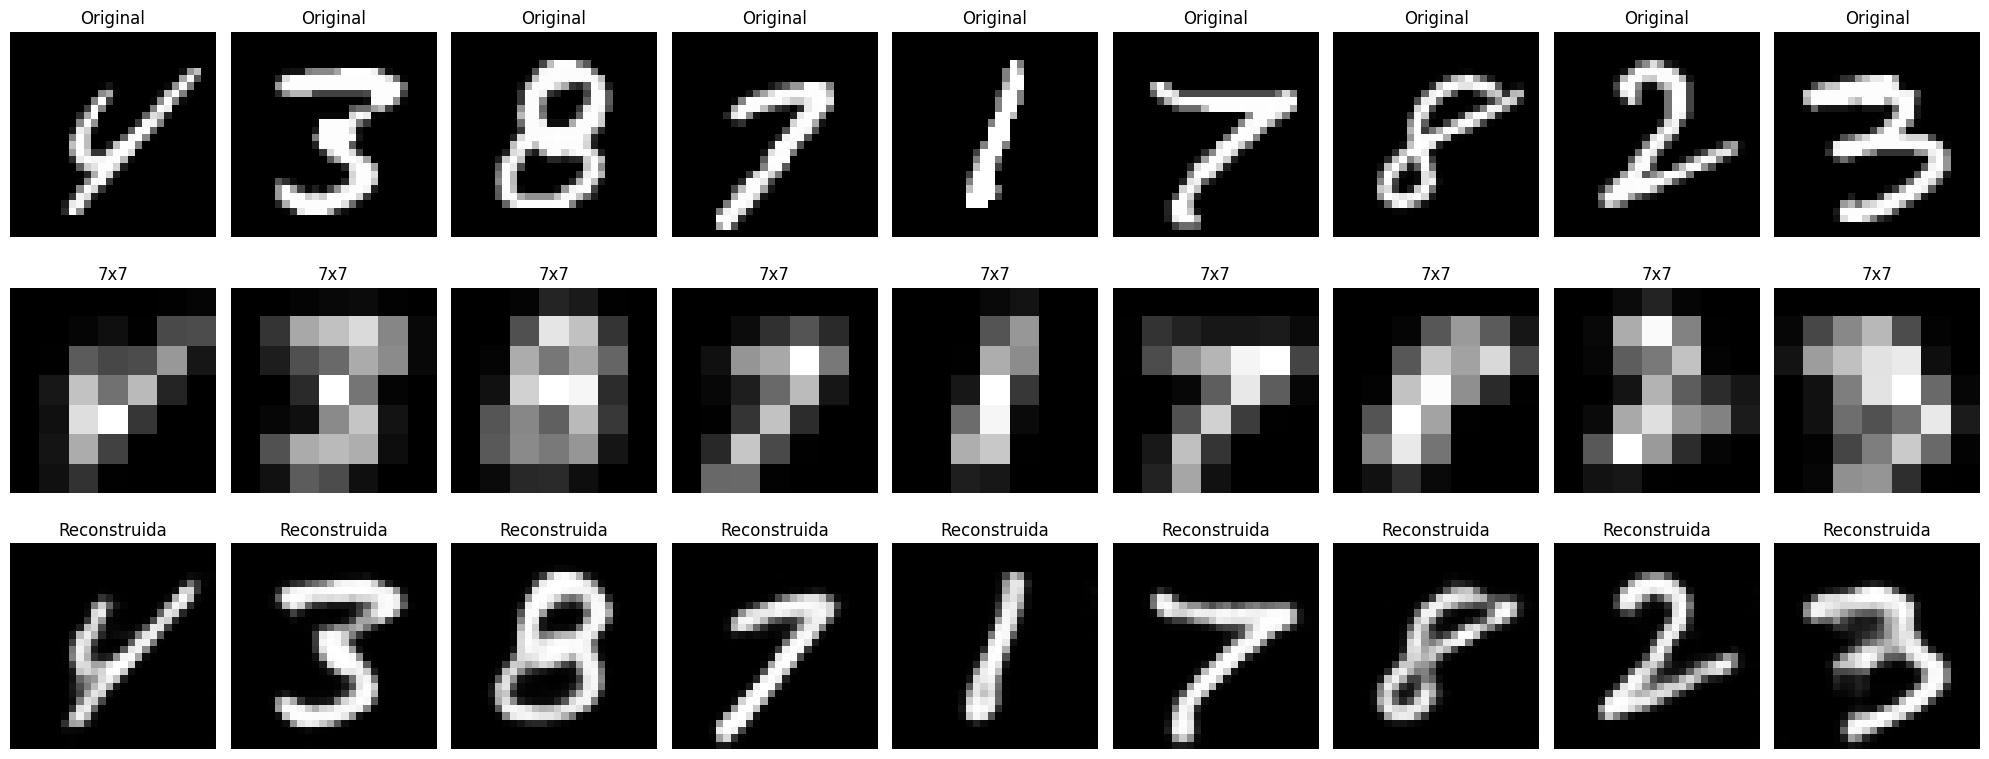

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder7x7().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-6)

num_epochs = 10


for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for images,_ in data_loader:

        original = images[0].to(device)
        resized = images[1].to(device)

        reconstructed = model(resized)

        loss = criterion(reconstructed, original)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(data_loader):.4f}")

model.eval()
img, _ = next(iter(data_loader_test))
originals, resized_images = img[0].to(device), img[1].to(device)
reconstructed = model(resized_images).detach().cpu()

def denormalize(img):
    return img * 0.5 + 0.5

originals = denormalize(originals).cpu()
resized_images = denormalize(resized_images).cpu()
reconstructed = denormalize(reconstructed)

fig, axes = plt.subplots(3, 9, figsize=(20, 8))
for i in range(9):

    axes[0, i].imshow(originals[i][0], cmap='gray')
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')

    axes[1, i].imshow(resized_images[i][0], cmap='gray')
    axes[1, i].set_title('7x7')
    axes[1, i].axis('off')

    axes[2, i].imshow(reconstructed[i][0], cmap='gray')
    axes[2, i].set_title('Reconstruida')
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

## Ejecucion con Autoencoder 14x14

**Entrenamiento y Visualización de Autoencoder 14x14**  
El modelo Autoencoder14x14 es entrenado para reconstruir imágenes redimensionadas de 14x14 a partir de imágenes originales de 28x28. Durante el entrenamiento, se usa la función de pérdida MSELoss y se optimiza el modelo con el optimizador Adam. Después de completar el entrenamiento, se visualizan las imágenes originales, redimensionadas y reconstruidas. Las imágenes son desnormalizadas para mostrar sus valores reales en el rango [0, 1] antes de la visualización.

Epoch [1/10], Loss: 0.0801
Epoch [2/10], Loss: 0.0122
Epoch [3/10], Loss: 0.0100
Epoch [4/10], Loss: 0.0090
Epoch [5/10], Loss: 0.0083
Epoch [6/10], Loss: 0.0078
Epoch [7/10], Loss: 0.0074
Epoch [8/10], Loss: 0.0071
Epoch [9/10], Loss: 0.0068
Epoch [10/10], Loss: 0.0066


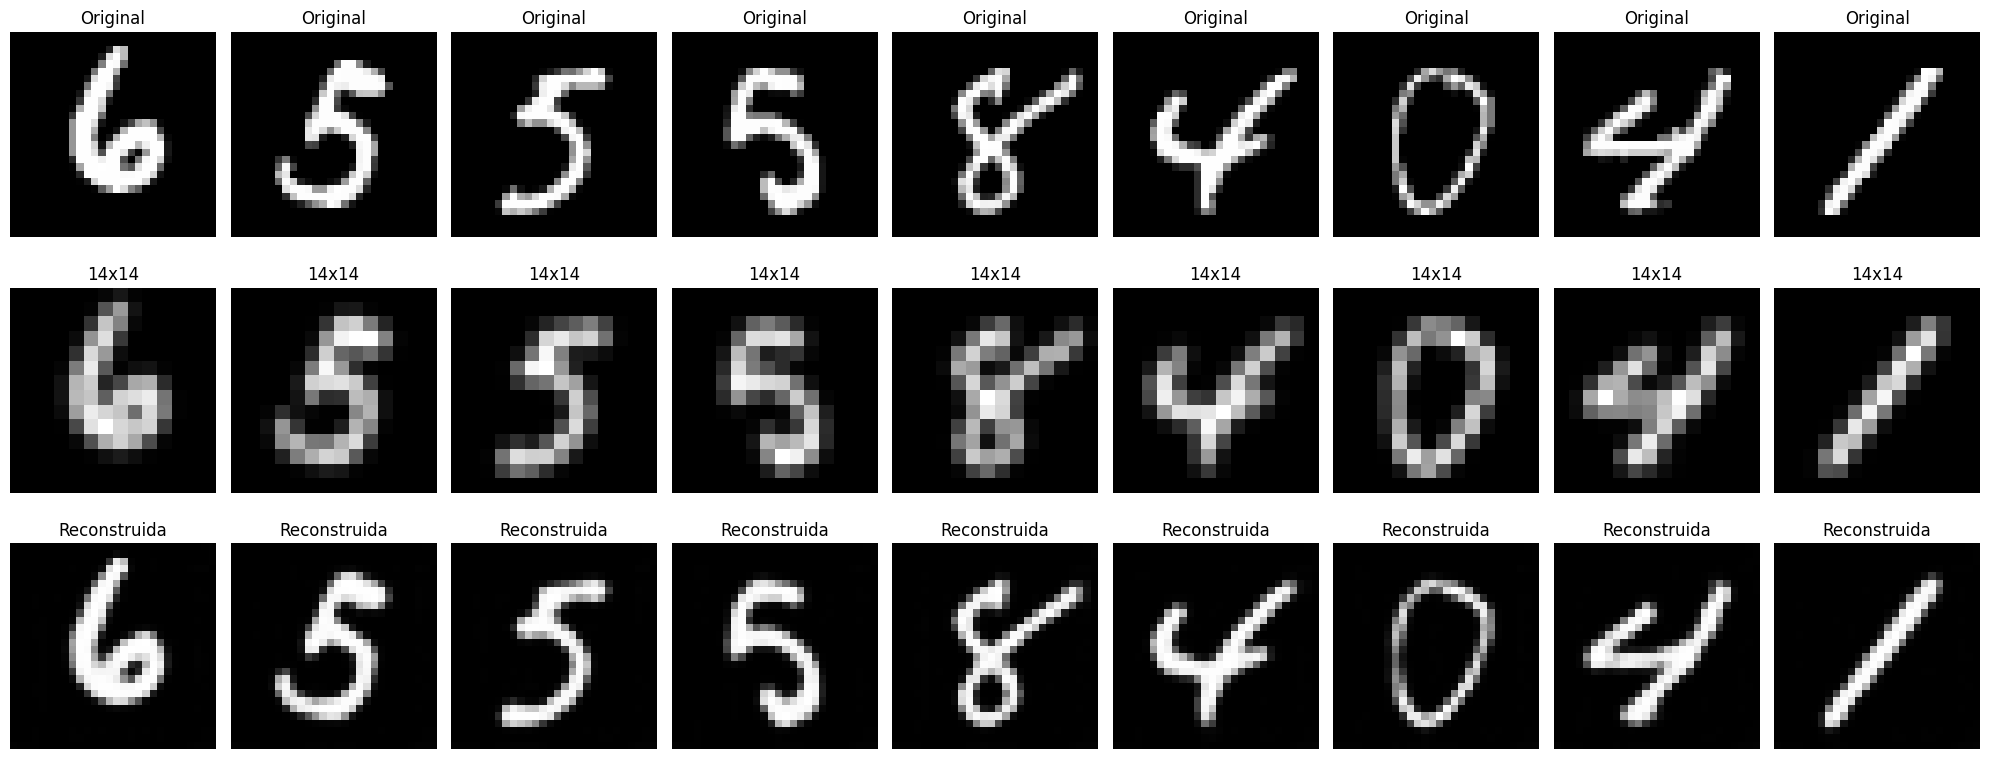

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder14x14().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-6)

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for images,_ in data_loader:

        original = images[0].to(device)
        resized = images[1].to(device)

        reconstructed = model(resized)

        loss = criterion(reconstructed, original)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(data_loader):.4f}")

model.eval()
img, _ = next(iter(data_loader_test))
originals, resized_images = img[0].to(device), img[1].to(device)
reconstructed = model(resized_images).detach().cpu()

def denormalize(img):
    return img * 0.5 + 0.5

originals = denormalize(originals).cpu()
resized_images = denormalize(resized_images).cpu()
reconstructed = denormalize(reconstructed)

fig, axes = plt.subplots(3, 9, figsize=(20, 8))
for i in range(9):

    axes[0, i].imshow(originals[i][0], cmap='gray')
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')

    axes[1, i].imshow(resized_images[i][0], cmap='gray')
    axes[1, i].set_title('14x14')
    axes[1, i].axis('off')

    axes[2, i].imshow(reconstructed[i][0], cmap='gray')
    axes[2, i].set_title('Reconstruida')
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()